In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
from pathlib import Path

META_DIR = Path('..') / 'meta_files'

Raw_data_path = '/Users/andrewleduc/Library/CloudStorage/GoogleDrive-research@slavovlab.net/My Drive/MS/Users/aleduc/AAS_rev/report.parquet'
AAS_fasta_path          = META_DIR / 'All_SAAP.fasta'
meta_data_file          = META_DIR / 'neuron_meta.csv'
AAS_peptide_mapping_file = META_DIR / 'Supplemental_Data_2.SAAP_proteins.xlsx'
high_quality_SAAPs      = META_DIR / 'high_quality_SAAPs.xlsx'
deg_data                = META_DIR / 'SILAC.xlsx'

## Load raw DIANN data and peptide mapping

In [51]:
# Load DIANN report
raw = pd.read_parquet(Raw_data_path)
print(f'Raw data shape: {raw.shape}')
raw.head(2)

Raw data shape: (2428268, 71)


,Run.Index,Run,Channel,Precursor.Id,Modified.Sequence,Stripped.Sequence,Precursor.Charge,Precursor.Lib.Index,Decoy,Proteotypic,...,Translated.Q.Value,Channel.Q.Value,PG.Q.Value,PG.PEP,GG.Q.Value,Protein.Q.Value,Global.PG.Q.Value,Lib.PG.Q.Value,Best.Fr.Mz,Best.Fr.Mz.Delta
0,19,220914_AM06_wc_14D_A4,,AAAAAAAAAAAAAAAGAGAGAK3,AAAAAAAAAAAAAAAGAGAGAK,AAAAAAAAAAAAAAAGAGAGAK,3,0,0,1,...,0.0,0.0,0.000170,0.000338,0.000167,0.000171,0.000163,0.000154,531.288513,-0.001343
1,21,220914_AM06_wc_14D_D2,,AAAAAAAAAAAAAAAGAGAGAK3,AAAAAAAAAAAAAAAGAGAGAK,AAAAAAAAAAAAAAAGAGAGAK,3,0,0,1,...,0.0,0.0,0.000171,0.000334,0.000166,0.000172,0.000163,0.000154,531.288513,0.000732


In [52]:
# Load AAS peptide mapping (SAAP -> BP pairs)
pep_map = pd.read_excel(AAS_peptide_mapping_file)
print(f'Peptide mapping shape: {pep_map.shape}')
pep_map[['SAAP', 'BP']].head()

Peptide mapping shape: (10180, 21)


,SAAP,BP
0,AGLGGPEAAK,AQLGGPEAAK
1,FFESFGDLSTPMAVMGNPK,FFESFGDLSTPDAVMGNPK
2,HQGVMVGDGQK,HQGVMVGMGQK
3,FFESFGDLSTPDAVDGNPK,FFESFGDLSTPDAVMGNPK
4,GTGCEPEEAVNIGDDCRDDVGGAQDVGMLGILVK,GTGCEPEEAVMIGDDCRDDVGGAQDVGMLGILVK


## Filter to SAAP and BP peptides present in the data

In [53]:
saap_set = set(pep_map['SAAP'].dropna().unique())
bp_set   = set(pep_map['BP'].dropna().unique())
all_peps = saap_set | bp_set

# Filter DIANN rows to only SAAP or BP peptides
mask = raw['Stripped.Sequence'].isin(all_peps)
filtered = raw.loc[mask].copy()
print(f'Rows matching SAAP/BP peptides: {len(filtered):,}')
print(f'Unique SAAP found: {filtered["Stripped.Sequence"].isin(saap_set).sum():,} rows')
print(f'Unique BP  found: {filtered["Stripped.Sequence"].isin(bp_set).sum():,} rows')

Rows matching SAAP/BP peptides: 97,951
Unique SAAP found: 9,977 rows
Unique BP  found: 87,974 rows


## Sum intensities per (Run, Stripped.Sequence) — collapse multiple precursor IDs

In [54]:
# Sum Ms1.Area and Precursor.Quantity across all precursor IDs for each
# unique (Run, Stripped.Sequence) combination
summed = (
    filtered
    .groupby(['Run', 'Stripped.Sequence'], as_index=False)
    [['Ms1.Area', 'Precursor.Quantity']]
    .sum()
)
print(f'Summed table shape: {summed.shape}')
summed.head()

Summed table shape: (66038, 4)


,Run,Stripped.Sequence,Ms1.Area,Precursor.Quantity
0,220914_AM06_wc_14D_A1,AAAPAPEEEMDECEQALAAEPK,4.539606e+07,4.064908e+07
1,220914_AM06_wc_14D_A1,AACQEAQVFGNQLIPPNAQVK,4.052021e+05,1.440764e+06
2,220914_AM06_wc_14D_A1,AADFQLHTHVNDGTEFGGSIYQK,3.628154e+06,2.066135e+06
3,220914_AM06_wc_14D_A1,AADFQLMTHVNDGTEFGGSIYQK,2.690762e+06,5.955358e+05
4,220914_AM06_wc_14D_A1,AAEDDEDDDVDTK,6.851142e+06,6.541072e+06


## Build SAAP / BP ratios per Run

In [55]:
# Keep only SAAP-BP pairs where BOTH peptides appear in the data
saap_data = summed[summed['Stripped.Sequence'].isin(saap_set)].rename(
    columns={'Stripped.Sequence': 'SAAP',
             'Ms1.Area': 'SAAP_Ms1',
             'Precursor.Quantity': 'SAAP_PQ'}
)
bp_data = summed[summed['Stripped.Sequence'].isin(bp_set)].rename(
    columns={'Stripped.Sequence': 'BP',
             'Ms1.Area': 'BP_Ms1',
             'Precursor.Quantity': 'BP_PQ'}
)

# Merge pep_map (unique SAAP-BP pairs) with per-run intensities
pairs = pep_map[['SAAP', 'BP']].drop_duplicates().dropna(subset=['SAAP', 'BP'])

ratios = (
    pairs
    .merge(saap_data, on='SAAP', how='inner')       # adds Run, SAAP_Ms1, SAAP_PQ
    .merge(bp_data,   on=['BP', 'Run'], how='inner') # adds BP_Ms1, BP_PQ
)

# Compute ratios (SAAP / BP)
ratios['MS1_ratio'] = ratios['SAAP_Ms1'] / ratios['BP_Ms1']
ratios['MS2_ratio'] = ratios['SAAP_PQ']  / ratios['BP_PQ']

# Drop rows where either ratio is undefined
ratios = ratios.replace([np.inf, -np.inf], np.nan).dropna(subset=['MS1_ratio', 'MS2_ratio'])
print(f'SAAP-BP ratio pairs: {len(ratios):,}')
ratios[['Run', 'SAAP', 'BP', 'MS1_ratio', 'MS2_ratio']].head()

SAAP-BP ratio pairs: 7,529


,Run,SAAP,BP,MS1_ratio,MS2_ratio
0,220914_AM06_wc_14D_A1,HIADLAGNSEVILPVPAMNVINGGSHAGNK,HIADLAGNSEVILPVPAFNVINGGSHAGNK,0.042476,0.043601
1,220914_AM06_wc_14D_A2,HIADLAGNSEVILPVPAMNVINGGSHAGNK,HIADLAGNSEVILPVPAFNVINGGSHAGNK,0.035135,0.038051
2,220914_AM06_wc_14D_A3,HIADLAGNSEVILPVPAMNVINGGSHAGNK,HIADLAGNSEVILPVPAFNVINGGSHAGNK,0.051820,0.056945
3,220914_AM06_wc_14D_A4,HIADLAGNSEVILPVPAMNVINGGSHAGNK,HIADLAGNSEVILPVPAFNVINGGSHAGNK,0.049600,0.051023
4,220914_AM06_wc_14D_D1,HIADLAGNSEVILPVPAMNVINGGSHAGNK,HIADLAGNSEVILPVPAFNVINGGSHAGNK,0.046119,0.038244


## Scatter plot: MS1 ratio vs MS2 (Precursor.Quantity) ratio

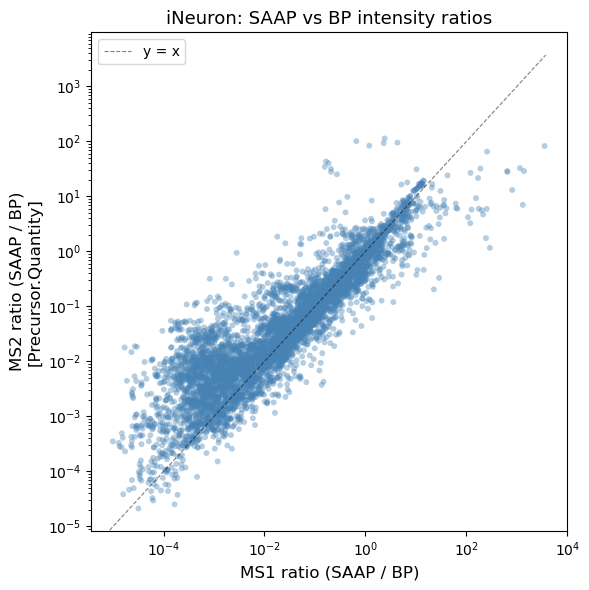

n = 7529 data points
MS1 ratio  median: 0.0152
MS2 ratio  median: 0.0369


In [56]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    ratios['MS1_ratio'],
    ratios['MS2_ratio'],
    alpha=0.4, s=18, edgecolors='none', color='steelblue'
)

# Reference diagonal
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5, label='y = x')

ax.set_xlabel('MS1 ratio (SAAP / BP)', fontsize=12)
ax.set_ylabel('MS2 ratio (SAAP / BP)\n[Precursor.Quantity]', fontsize=12)
ax.set_title('iNeuron: SAAP vs BP intensity ratios', fontsize=13)
ax.legend(fontsize=10)

# Log scale if ratios span orders of magnitude
if ratios['MS1_ratio'].max() / (ratios['MS1_ratio'].min() + 1e-12) > 100:
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('iNeuron_SAAP_BP_ratios.pdf', dpi=150)
plt.show()

print(f'n = {len(ratios)} data points')
print(f'MS1 ratio  median: {ratios["MS1_ratio"].median():.4f}')
print(f'MS2 ratio  median: {ratios["MS2_ratio"].median():.4f}')

## Unique SAAPs detected per Raw file and per Condition

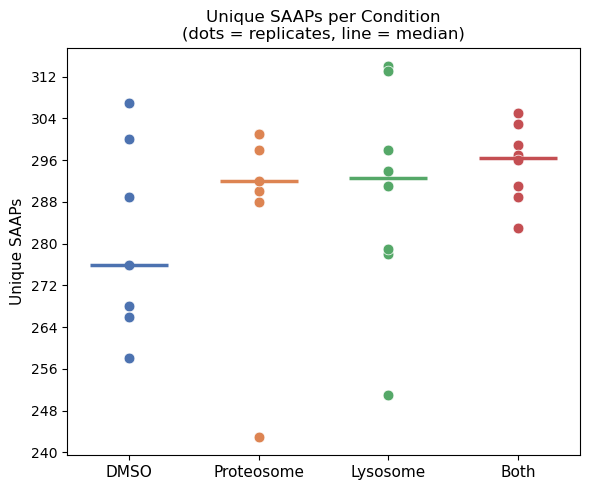

In [57]:
from matplotlib.patches import Patch

# Load metadata and strip .raw extension to match Run column
meta = pd.read_csv(meta_data_file)
meta['Run'] = meta['Raw'].str.replace('.raw', '', regex=False)

# Count unique SAAPs per Run
saap_only = filtered[filtered['Stripped.Sequence'].isin(saap_set)].copy()
unique_per_run = (
    saap_only
    .groupby('Run')['Stripped.Sequence']
    .nunique()
    .reset_index()
    .rename(columns={'Stripped.Sequence': 'Unique_SAAPs'})
)
unique_per_run = unique_per_run.merge(meta[['Run', 'Day', 'Condition']], on='Run', how='left')

condition_order = ['DMSO', 'Proteosome', 'Lysosome', 'Both']
cond_colors = {'DMSO': '#4C72B0', 'Proteosome': '#DD8452', 'Lysosome': '#55A868', 'Both': '#C44E52'}

fig, ax = plt.subplots(figsize=(6, 5))
for i, cond in enumerate(condition_order):
    subset = unique_per_run[unique_per_run['Condition'] == cond]['Unique_SAAPs']
    ax.scatter([i] * len(subset), subset, color=cond_colors[cond], s=60, zorder=3, edgecolors='white', linewidths=0.5)
    ax.hlines(subset.median(), i - 0.3, i + 0.3, colors=cond_colors[cond], linewidths=2.5, zorder=4)

ax.set_xticks(range(len(condition_order)))
ax.set_xticklabels(condition_order, fontsize=11)
ax.set_ylabel('Unique SAAPs', fontsize=11)
ax.set_title('Unique SAAPs per Condition\n(dots = replicates, line = median)', fontsize=12)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('iNeuron_unique_SAAPs_per_condition.pdf', dpi=150)
plt.show()


## Unique total peptides (SAAP + BP) detected per Condition

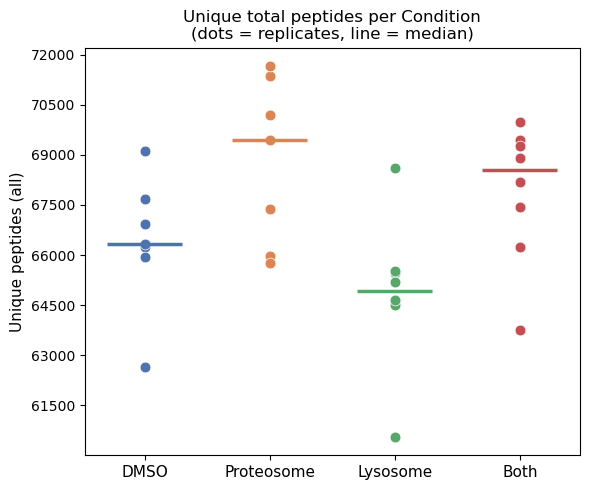

In [58]:
# Count unique total peptides (all peptides in raw data) per Run
unique_total_per_run = (
    raw
    .groupby('Run')['Stripped.Sequence']
    .nunique()
    .reset_index()
    .rename(columns={'Stripped.Sequence': 'Unique_Peptides'})
)
unique_total_per_run = unique_total_per_run.merge(meta[['Run', 'Day', 'Condition']], on='Run', how='left')

fig, ax = plt.subplots(figsize=(6, 5))
for i, cond in enumerate(condition_order):
    subset = unique_total_per_run[unique_total_per_run['Condition'] == cond]['Unique_Peptides']
    ax.scatter([i] * len(subset), subset, color=cond_colors[cond], s=60, zorder=3, edgecolors='white', linewidths=0.5)
    ax.hlines(subset.median(), i - 0.3, i + 0.3, colors=cond_colors[cond], linewidths=2.5, zorder=4)

ax.set_xticks(range(len(condition_order)))
ax.set_xticklabels(condition_order, fontsize=11)
ax.set_ylabel('Unique peptides (all)', fontsize=11)
ax.set_title('Unique total peptides per Condition\n(dots = replicates, line = median)', fontsize=12)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('iNeuron_unique_total_peptides_per_condition.pdf', dpi=150)
plt.show()


## Log2 RAAS ratios per Condition (SAAPs detected in all conditions)

SAAPs at least 2x slower deg than BP: 913
Rows after filter: 386
Unique SAAPs: 20
Points per condition: {'DMSO': 20, 'Proteosome': 17, 'Lysosome': 20, 'Both': 20}


/Users/andrewleduc/anaconda3/envs/CPTAC/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/7n/xnj310j510vfnmdrs9612db40000gn/T/ipykernel_79524/1560520195.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


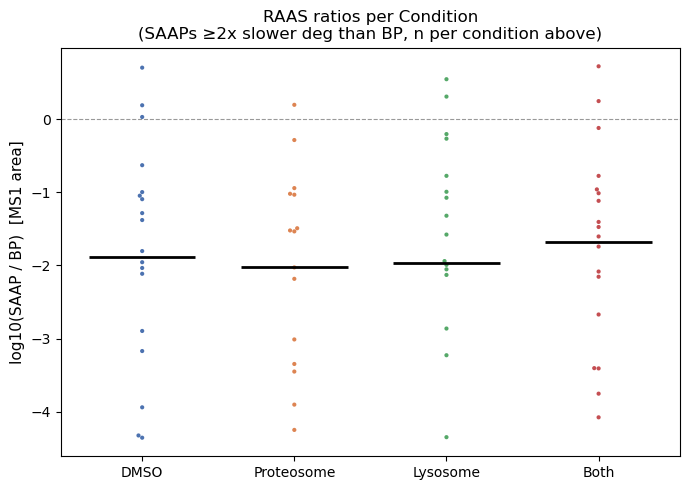

In [59]:
import seaborn as sns

# Load SILAC degradation rates; keep SAAPs where SAAP deg rate <= 0.5 * BP deg rate (at least 2x slower)
silac = pd.read_excel(deg_data)[['SAAP', 'BP', 'SAAP degradation rate [1/d]', 'BP degradation rate [1/d]']].dropna()
silac_mean = silac.groupby('SAAP')[['SAAP degradation rate [1/d]', 'BP degradation rate [1/d]']].mean()
slow_deg_saaps = set(silac_mean[silac_mean['SAAP degradation rate [1/d]'] <= silac_mean['BP degradation rate [1/d]'] / 2].index)
print(f'SAAPs at least 2x slower deg than BP: {len(slow_deg_saaps)}')

# Add Condition to ratios via metadata, restrict to filtered SAAPs
ratios_cond = ratios.merge(meta[['Run', 'Condition']], on='Run', how='left')
ratios_cond = ratios_cond[ratios_cond['SAAP'].isin(slow_deg_saaps)].copy()
ratios_cond['log10_MS1'] = np.log10(ratios_cond['MS1_ratio'])
print(f'Rows after filter: {len(ratios_cond):,}')

# Average log10 MS1 ratio per SAAP × Condition
mean_per_saap_cond = (
    ratios_cond
    .groupby(['SAAP', 'Condition'])['log10_MS1']
    .mean()
    .reset_index()
    .rename(columns={'log10_MS1': 'log10_MS1_ratio'})
)
mean_per_saap_cond['Condition'] = pd.Categorical(
    mean_per_saap_cond['Condition'], categories=condition_order, ordered=True)

print(f'Unique SAAPs: {mean_per_saap_cond["SAAP"].nunique()}')
print(f'Points per condition: {mean_per_saap_cond.groupby("Condition", observed=True).size().to_dict()}')

# Beeswarm + median lines
fig, ax = plt.subplots(figsize=(7, 5))
sns.swarmplot(
    data=mean_per_saap_cond, x='Condition', y='log10_MS1_ratio',
    order=condition_order, palette=cond_colors, size=3, ax=ax
)

for i, cond in enumerate(condition_order):
    med = mean_per_saap_cond[mean_per_saap_cond['Condition'] == cond]['log10_MS1_ratio'].median()
    ax.hlines(med, i - 0.35, i + 0.35, colors='black', linewidths=2, zorder=5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('')
ax.set_ylabel('log10(SAAP / BP)  [MS1 area]', fontsize=11)
ax.set_title(f'RAAS ratios per Condition\n(SAAPs ≥2x slower deg than BP, n per condition above)', fontsize=12)

plt.tight_layout()
plt.savefig('iNeuron_RAAS_log10_per_condition.pdf', dpi=150)
plt.show()


## RAAS ratios normalized across conditions (per-SAAP mean subtracted)

NaN check: 10 NaNs out of 77


/Users/andrewleduc/anaconda3/envs/CPTAC/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


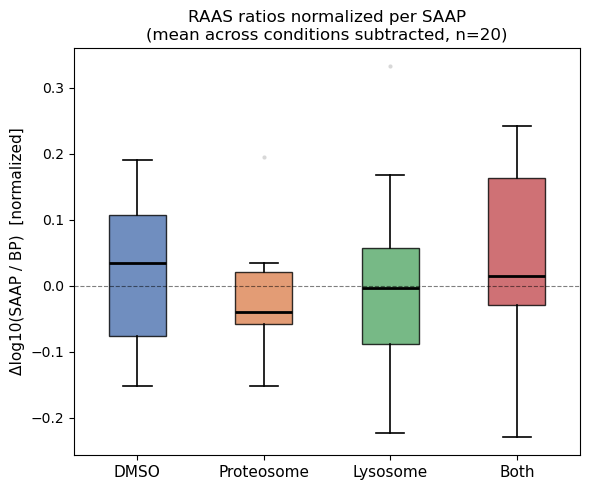

In [60]:
# Subtract each SAAP's mean log10 ratio across all conditions
saap_mean = (
    mean_per_saap_cond
    .groupby('SAAP')['log10_MS1_ratio']
    .mean()
    .reset_index()
    .rename(columns={'log10_MS1_ratio': 'saap_mean'})
)
norm = mean_per_saap_cond.merge(saap_mean, on='SAAP', how='left')
norm['log10_ratio_norm'] = norm['log10_MS1_ratio'] - norm['saap_mean']

print(f'NaN check: {norm["log10_ratio_norm"].isna().sum()} NaNs out of {len(norm)}')

# Clip to 1st–99th percentile
lo_n, hi_n = np.percentile(norm['log10_ratio_norm'].dropna(), [1, 99])
norm['log10_ratio_norm_clipped'] = norm['log10_ratio_norm'].clip(lo_n, hi_n)

# Box plot of normalized ratios
fig, ax = plt.subplots(figsize=(6, 5))
data_norm = [norm[norm['Condition'] == c]['log10_ratio_norm_clipped'].dropna().values
             for c in condition_order]

bp = ax.boxplot(data_norm, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3,
                                markerfacecolor='grey', markeredgewidth=0))
for patch, cond in zip(bp['boxes'], condition_order):
    patch.set_facecolor(cond_colors[cond])
    patch.set_alpha(0.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(range(1, len(condition_order) + 1))
ax.set_xticklabels(condition_order, fontsize=11)
ax.set_ylabel('Δlog10(SAAP / BP)  [normalized]', fontsize=11)
ax.set_title(f'RAAS ratios normalized per SAAP\n(mean across conditions subtracted, n={norm["SAAP"].nunique()})', fontsize=12)

plt.tight_layout()
plt.savefig('iNeuron_RAAS_log10_normalized_per_condition.pdf', dpi=150)
plt.show()
